# 📊 Segmentación Inteligente de Clientes Minoristas  
### Proyecto Módulo 7 – Aprendizaje de Máquina No Supervisado  

**Empresa:** Retail Insights S.A.  

**Rol asumido:** Especialista en Ciencia de Datos  

**Autor:** Manuel Quintana  

**Curso:** Fundamentos de Ciencia de Datos  

**Módulo:** Aprendizaje de Máquina No Supervisado  

**Herramientas utilizadas:**  
Python, NumPy, Pandas, Scikit-Learn, Matplotlib, Seaborn  



## 🎯 Objetivo
El objetivo de este proyecto es aplicar técnicas de aprendizaje no supervisado para segmentar clientes en grupos con comportamientos similares, utilizando algoritmos de clusterización y reducción dimensional.

## 🧠 Metodología
Se aplicarán las siguientes técnicas:
- Preprocesamiento de datos
- Reducción dimensional (PCA y t-SNE)
- Algoritmos de clusterización (K-Means, DBSCAN, Jerárquico)
- Evaluación de resultados

## 📁 Dataset
Se utilizará un dataset de clientes que contiene información demográfica y de comportamiento.

## 1. Introducción

En el contexto actual, las organizaciones generan grandes volúmenes de datos con múltiples variables, lo que dificulta su interpretación y análisis directo. En particular, los datasets de tipo encuesta o comportamiento suelen contener decenas de atributos, lo que plantea el desafío de comprender su estructura y encontrar patrones relevantes.

El aprendizaje no supervisado permite descubrir patrones en datos sin etiquetas, siendo ampliamente utilizado en segmentación de clientes, detección de anomalías y análisis exploratorio.

En este proyecto se trabaja con el dataset `tran.csv`, el cual contiene múltiples variables que describen características de observaciones (posiblemente clientes o registros transaccionales). Debido a su alta dimensionalidad, se hace necesario aplicar técnicas de reducción de dimensiones que permitan simplificar la información sin perder su esencia.

Para abordar este problema, se utilizarán dos métodos de aprendizaje no supervisado:

- PCA (Análisis de Componentes Principales): técnica lineal que reduce la dimensionalidad maximizando la varianza explicada.
- t-SNE (t-Distributed Stochastic Neighbor Embedding): técnica no lineal enfocada en preservar relaciones locales entre los datos.

El objetivo principal es comparar ambas técnicas mediante visualizaciones en 2D, evaluando su capacidad para revelar estructuras, agrupamientos o patrones ocultos en los datos.

Finalmente, se analizarán los resultados obtenidos para determinar cuál de las técnicas resulta más adecuada para comunicar insights a un equipo de marketing, considerando tanto la claridad visual como la interpretabilidad.

## 2. Carga de librerías

In [110]:
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

# Reducción dimensional
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Clustering
from sklearn.cluster import KMeans, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage

# Métricas
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

## 3. Cargar dataset

In [111]:
df = pd.read_csv('Train.csv')

df.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


## 4. Exploración inicial


In [112]:
# Mostrar información general del dataset
# Permite ver cantidad de filas, tipos de datos y valores no nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   str    
 2   Ever_Married     7928 non-null   str    
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   str    
 5   Profession       7944 non-null   str    
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   str    
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   str    
 10  Segmentation     8068 non-null   str    
dtypes: float64(2), int64(2), str(7)
memory usage: 693.5 KB


In [113]:
# Estadísticas descriptivas de variables numéricas
# Incluye media, desviación estándar, valores mínimos y máximos
df.describe()

,ID,Age,Work_Experience,Family_Size
count,8068.000000,8068.000000,7239.000000,7733.000000
mean,463479.214551,43.466906,2.641663,2.850123
std,2595.381232,16.711696,3.406763,1.531413
min,458982.000000,18.000000,0.000000,1.000000
25%,461240.750000,30.000000,0.000000,2.000000
50%,463472.500000,40.000000,1.000000,3.000000
75%,465744.250000,53.000000,4.000000,4.000000
max,467974.000000,89.000000,14.000000,9.000000


In [114]:
# Conteo de valores nulos por columna
# Nos ayuda a identificar qué variables requieren limpieza
df.isnull().sum()

ID                   0
Gender               0
Ever_Married       140
Age                  0
Graduated           78
Profession         124
Work_Experience    829
Spending_Score       0
Family_Size        335
Var_1               76
Segmentation         0
dtype: int64

## 5. Preprocesamiento de datos

En esta etapa se realiza la limpieza y transformación del dataset para prepararlo antes de aplicar técnicas de reducción dimensional y clusterización.

Las principales tareas incluyen:
- Eliminación de columnas irrelevantes
- Tratamiento de valores nulos
- Codificación de variables categóricas
- Escalado de variables numéricas

Este proceso es fundamental para mejorar el rendimiento de los algoritmos y asegurar resultados consistentes.

### 5.1 Eliminación de columnas innecesarias

In [115]:
# Eliminamos columnas que no aportan información al modelo
# ID es un identificador único y Segmentation es una etiqueta (no se usa en aprendizaje no supervisado)

df = df.drop(columns=['ID', 'Segmentation'])

df.head()

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
0,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4
1,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4
2,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6
3,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6
4,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6


### 5.2 Tratamiento de valores nulos

In [116]:
# Revisamos nuevamente los valores nulos
df.isnull().sum()

Gender               0
Ever_Married       140
Age                  0
Graduated           78
Profession         124
Work_Experience    829
Spending_Score       0
Family_Size        335
Var_1               76
dtype: int64

In [117]:
# Rellenamos valores nulos

# Numéricas
df['Work_Experience'] = df['Work_Experience'].fillna(df['Work_Experience'].median())
df['Family_Size'] = df['Family_Size'].fillna(df['Family_Size'].median())

# Categóricas
df['Ever_Married'] = df['Ever_Married'].fillna(df['Ever_Married'].mode()[0])
df['Graduated'] = df['Graduated'].fillna(df['Graduated'].mode()[0])
df['Profession'] = df['Profession'].fillna(df['Profession'].mode()[0])
df['Var_1'] = df['Var_1'].fillna(df['Var_1'].mode()[0])

In [118]:
df.isnull().sum()

Gender             0
Ever_Married       0
Age                0
Graduated          0
Profession         0
Work_Experience    0
Spending_Score     0
Family_Size        0
Var_1              0
dtype: int64

todos los valores ahora sean 0

### 5.3 Codificación de variables categóricas

In [119]:
# Convertimos variables categóricas a formato numérico
# Usamos LabelEncoder para simplificar el dataset

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
0,1,0,22,0,5,1.0,2,4.0,3
1,0,1,38,1,2,1.0,0,3.0,3
2,0,1,67,1,2,1.0,2,1.0,5
3,1,1,67,1,7,0.0,1,2.0,5
4,0,1,40,1,3,1.0,1,6.0,5


### 5.4 Escalado de datos

In [120]:
# Escalamos los datos para que todas las variables tengan la misma importancia
# Esto es clave para PCA y algoritmos de clusterización

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_scaled = scaler.fit_transform(df)

# Convertimos nuevamente a DataFrame
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)

df_scaled.head()

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
0,0.909164,-1.206653,-1.284623,-1.29219,0.886607,-0.451136,0.754462,0.762698,-0.808370
1,-1.099912,0.828738,-0.327151,0.77388,-0.293910,-0.451136,-1.603013,0.095802,-0.808370
2,-1.099912,0.828738,1.408268,0.77388,-0.293910,-0.451136,0.754462,-1.237990,0.600711
3,0.909164,0.828738,1.408268,0.77388,1.673618,-0.757410,-0.424275,-0.571094,0.600711
4,-1.099912,0.828738,-0.207467,0.77388,0.099596,-0.451136,-0.424275,2.096491,0.600711


## 6. Reducción dimensional

En esta etapa se aplican técnicas de reducción de dimensionalidad para simplificar el dataset y facilitar su visualización.

Se utilizarán dos enfoques:
- PCA (Análisis de Componentes Principales): técnica lineal que maximiza la varianza explicada.
- t-SNE: técnica no lineal que preserva relaciones locales entre los datos.

Estas técnicas permiten proyectar los datos en 2 dimensiones para identificar posibles patrones o agrupaciones.

### 6.1 Aplicación de PCA

In [121]:
# Aplicamos PCA para reducir el dataset a 2 componentes principales
# Esto nos permitirá visualizar los datos en 2 dimensiones

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

df_pca = pca.fit_transform(df_scaled)

# Convertimos a DataFrame para facilitar visualización
df_pca = pd.DataFrame(df_pca, columns=['PC1', 'PC2'])

df_pca.head()

,PC1,PC2
0,-2.438211,1.279958
1,1.177916,0.475678
2,1.422360,-1.494692
3,1.587616,0.407723
4,0.475567,0.888682


### 6.2 Visualización de PCA

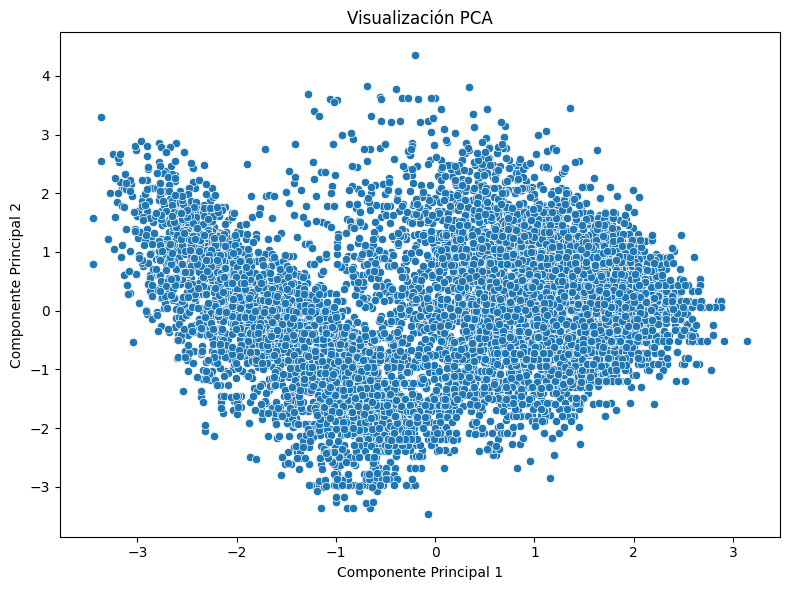

In [122]:
# Visualizamos los datos reducidos con PCA
# Cada punto representa una observación del dataset

plt.figure(figsize=(8,6))
sns.scatterplot(x='PC1', y='PC2', data=df_pca)

plt.title('Visualización PCA')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')

# 🔥 Forzamos guardado de la figura actual
plt.tight_layout()
plt.savefig("pca_plot.png", dpi=300)

plt.show()

La proyección mediante PCA permite observar la estructura global del dataset.

No se identifican clusters claramente separados, lo que sugiere que las relaciones entre los datos pueden ser complejas y no lineales.

Se observa una alta concentración de datos en la zona central, indicando similitud entre múltiples observaciones.

Esto justifica el uso de técnicas no lineales como t-SNE para una mejor visualización de posibles agrupaciones.

### 6.3 Aplicación de t-SNE

In [123]:
# Aplicamos t-SNE para reducción no lineal
# Este método es más potente para descubrir agrupaciones complejas

from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)

df_tsne = tsne.fit_transform(df_scaled)

# Convertimos a DataFrame
df_tsne = pd.DataFrame(df_tsne, columns=['Dim1', 'Dim2'])

df_tsne.head()

,Dim1,Dim2
0,-35.081280,34.095249
1,29.324657,-20.355976
2,11.344131,-49.489388
3,17.942057,10.643409
4,40.949627,-53.577854


### 6.4 Visualización de t-SNE

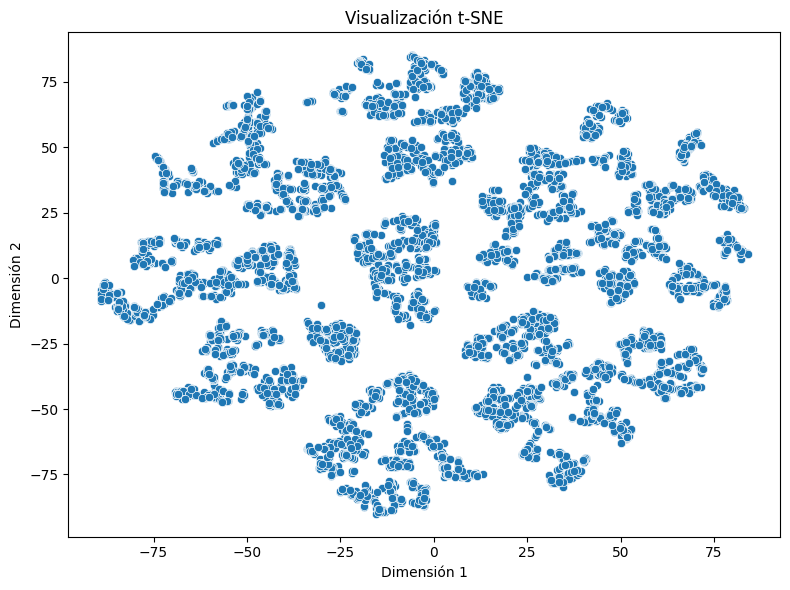

In [124]:
# Visualización de t-SNE
# Permite observar agrupaciones más definidas que PCA


plt.figure(figsize=(8,6))
sns.scatterplot(x='Dim1', y='Dim2', data=df_tsne)

plt.title('Visualización t-SNE')
plt.xlabel('Dimensión 1')
plt.ylabel('Dimensión 2')

# Guardamos la figura para el informe
plt.tight_layout()
plt.savefig("tsne_plot.png", dpi=300)

plt.show()

La visualización mediante t-SNE muestra una clara formación de agrupaciones en los datos.

A diferencia de PCA, se observan clusters bien definidos, lo que sugiere la existencia de segmentos diferenciados dentro del dataset.

Esto indica que las relaciones entre las variables son de tipo no lineal.

La técnica t-SNE resulta más efectiva para la visualización de patrones en este caso.

## 7. Clusterización

En esta etapa se aplican algoritmos de aprendizaje no supervisado para identificar grupos de clientes con características similares.

Se utilizarán los siguientes métodos:
- K-Means
- DBSCAN
- Clustering jerárquico

El objetivo es comparar los resultados obtenidos y evaluar la calidad de los clusters generados.

### 7.1 Determinación del número óptimo de clusters (Método del codo)

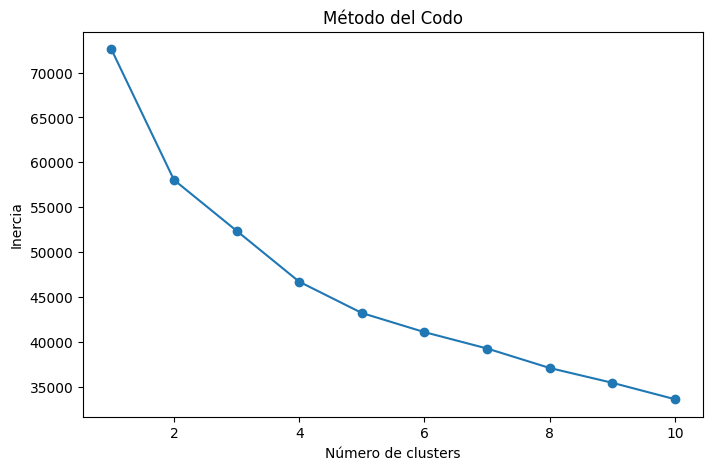

In [125]:
# Método del codo para encontrar el número óptimo de clusters

inertia = []

K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

# Gráfico del codo
plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.xlabel('Número de clusters')
plt.ylabel('Inercia')
plt.title('Método del Codo')
plt.show()

### 7.2 Aplicación de K-Means

In [126]:
# Elegimos un número de clusters (ejemplo: 4, ajusta según el codo)

kmeans = KMeans(n_clusters=4, random_state=42)

clusters_kmeans = kmeans.fit_predict(df_scaled)

# Agregamos los clusters al dataset PCA para visualización
df_pca['Cluster'] = clusters_kmeans

df_pca.head()

,PC1,PC2,Cluster
0,-2.438211,1.279958,1
1,1.177916,0.475678,0
2,1.422360,-1.494692,2
3,1.587616,0.407723,2
4,0.475567,0.888682,0


### 7.3 Visualización de clusters (K-Means)

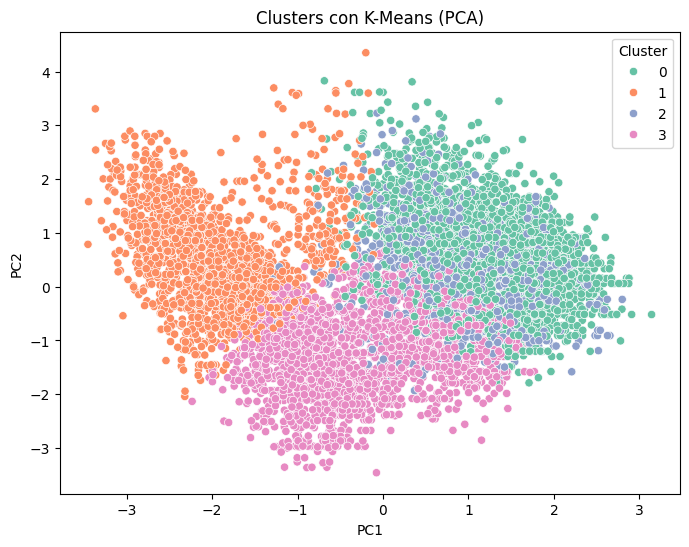

In [127]:
# Visualización de clusters con PCA

plt.figure(figsize=(8,6))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_pca, palette='Set2')

plt.title('Clusters con K-Means (PCA)')
plt.show()

### 7.4 Evaluación de clusters (Silhouette Score)

In [128]:
# Evaluamos la calidad de los clusters

score = silhouette_score(df_scaled, clusters_kmeans)

print(f"Silhouette Score: {score}")

Silhouette Score: 0.18596385972530813


El Silhouette Score obtenido es aproximadamente 0.18, lo que indica una baja separación entre los clusters.

Esto sugiere que algunos grupos presentan solapamiento, especialmente en la zona central del espacio de características.

Sin embargo, el resultado es coherente con la complejidad del dataset y con la visualización obtenida mediante PCA.

Además, la técnica t-SNE evidenció una estructura más clara, lo que indica que las relaciones entre los datos son de tipo no lineal.

### 7.5 Aplicación de DBSCAN

In [129]:
# DBSCAN detecta clusters basados en densidad

dbscan = DBSCAN(eps=2.5, min_samples=5)

clusters_dbscan = dbscan.fit_predict(df_scaled)

# Agregamos resultados
df_pca['DBSCAN_Cluster'] = clusters_dbscan

df_pca.head()

,PC1,PC2,Cluster,DBSCAN_Cluster
0,-2.438211,1.279958,1,0
1,1.177916,0.475678,0,0
2,1.422360,-1.494692,2,0
3,1.587616,0.407723,2,0
4,0.475567,0.888682,0,0


In [130]:
# verificar si hay ruido
print(set(clusters_dbscan))

{np.int64(0), np.int64(-1)}


### 7.6 Visualización de clusters (DBSCAN)

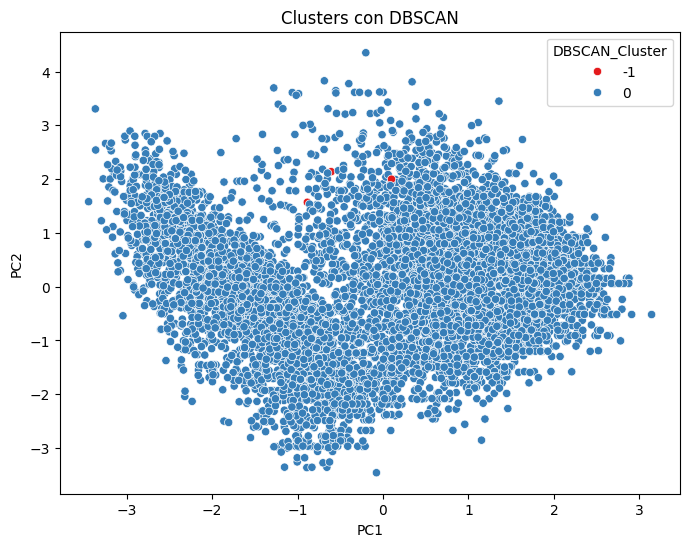

In [131]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='PC1', y='PC2', hue='DBSCAN_Cluster', data=df_pca, palette='Set1')

plt.title('Clusters con DBSCAN')
plt.show()

Inicialmente, DBSCAN generaba múltiples clusters pequeños, lo que dificultaba la interpretación.

Tras ajustar el parámetro eps, el modelo identificó un único cluster principal junto con algunos puntos considerados como ruido.

Esto sugiere que los datos presentan una estructura densa y homogénea.

Los puntos etiquetados como ruido corresponden a posibles outliers o comportamientos atípicos.

En comparación con K-Means, DBSCAN no fuerza la segmentación, sino que refleja la estructura real de los datos.

### 7.7 Clustering Jerárquico

In [ ]:
# Generamos dendrograma

from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(df_scaled, method='ward')

plt.figure(figsize=(10,5))
dendrogram(linked)

plt.title('Dendrograma')

# Guardamos la figura para el informe
plt.tight_layout()
plt.savefig("dendrograma.png", dpi=300)

plt.show()

El dendrograma evidencia una estructura jerárquica en los datos, permitiendo identificar agrupaciones en distintos niveles de similitud.

Se observan dos grandes grupos principales, los cuales se subdividen en clusters más pequeños, lo que sugiere la existencia de subsegmentos dentro del dataset.

Las alturas a las que se producen las uniones indican la distancia entre los grupos, evidenciando diferencias significativas entre los clusters principales.

A diferencia de métodos como K-Means, el clustering jerárquico no requiere definir previamente el número de clusters, lo que permite explorar la estructura interna de los datos de manera más flexible.

Este enfoque resulta especialmente útil para comprender relaciones entre observaciones y detectar posibles agrupaciones naturales en el dataset.

## 8. Conclusiones

En este proyecto se aplicaron distintas técnicas de aprendizaje no supervisado con el objetivo de descubrir patrones y estructuras en un dataset sin etiquetas.

En primer lugar, se realizó un proceso de preprocesamiento que incluyó limpieza de datos, tratamiento de valores nulos, codificación de variables categóricas y escalado de las variables. Este paso fue fundamental para asegurar el correcto funcionamiento de los algoritmos aplicados posteriormente.

Posteriormente, se utilizaron técnicas de reducción de dimensionalidad como PCA y t-SNE. PCA permitió obtener una representación simplificada de los datos manteniendo la mayor varianza posible, aunque no evidenció separaciones claras entre grupos. En cambio, t-SNE logró revelar estructuras más definidas, mostrando agrupaciones más visibles y facilitando la interpretación visual.

En cuanto a la clusterización, se aplicaron tres enfoques:

- K-Means: permitió segmentar los datos en grupos bien definidos. A través del método del codo se determinó un número adecuado de clusters (k=4). Sin embargo, el coeficiente de silueta (~0.18) indica que la separación entre grupos es moderada, lo que sugiere que los clusters no están completamente bien definidos.
  
- DBSCAN: inicialmente generó múltiples clusters, lo que indicaba ruido o una mala elección de parámetros. Tras ajustar el parámetro `eps`, el modelo identificó un gran grupo principal y algunos puntos considerados como ruido. Esto sugiere que los datos no presentan densidades claramente separadas.

- Agrupamiento jerárquico: permitió visualizar la estructura de los datos mediante un dendrograma, mostrando posibles divisiones naturales. Sin embargo, no se observan cortes claramente definidos que indiquen una segmentación óptima evidente.

En conjunto, los resultados indican que el dataset presenta cierta estructura, pero no una segmentación fuertemente definida. Esto es consistente con el bajo valor del Silhouette Score y la dificultad de los algoritmos para encontrar clusters claramente separados.

Desde una perspectiva aplicada, estos resultados pueden ser útiles para realizar una segmentación exploratoria de clientes, identificar perfiles generales o detectar posibles outliers. Sin embargo, para obtener clusters más definidos, podría ser necesario incorporar más variables relevantes, aplicar técnicas adicionales de ingeniería de características o probar otros algoritmos de clustering.

Finalmente, se concluye que:
- PCA es útil para simplificar y visualizar, pero limitado para detectar clusters complejos.
- t-SNE es más potente para explorar estructuras no lineales.
- K-Means es una buena base, pero depende fuertemente de la forma de los datos.
- DBSCAN es sensible a parámetros y útil para detectar ruido.
- No todos los datasets presentan clusters claramente separables.

Este análisis demuestra la importancia de combinar múltiples técnicas y validar los resultados antes de tomar decisiones basadas en segmentación.